# Number Labyrinth — Generator Analysis

This notebook analyses and develops the number-generation algorithm for the
**Number Labyrinth** game (`src/games/NumberLabyrinth/index.jsx`).

## Scope (this notebook)
1. Python port of the **solution-path generator** (direct translation of the JS source).
2. A **board display** function that renders the grid and highlights the solution path.
3. A **BFS exhaustive enumerator** (`generate_solution_path_2`) that finds every valid path
   within optional length bounds, using those bounds to prune the search tree.
4. **Visual comparison** of shortest vs. longest valid paths for levels 1–4.

The full number-filling algorithm (steps 2–4) is left for a later cell once the
path-quality analysis is complete.

---
## 1 · Imports & level config

In [1]:
import random
import math
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Level config — mirrors LEVELS in index.jsx
LEVELS = {
    1: dict(cols=4, rows=5, min_val=0,  max_val=120),
    2: dict(cols=5, rows=5, min_val=0,  max_val=300),
    3: dict(cols=6, rows=6, min_val=0,  max_val=500),
    4: dict(cols=7, rows=7, min_val=0,  max_val=700),
    5: dict(cols=8, rows=8, min_val=8,  max_val=999),
}

---
## 2 · Solution-path generator (v1 — original JS port)

Direct Python translation of `generateSolutionPath` in `index.jsx`.

### Algorithm summary
* Target path length: between `0.35 × T` and `0.55 × T` cells (T = cols × rows).
* **Biased random walk** from `(0,0)` toward `(cols-1, rows-1)`:
  * At each step, only neighbours that can still reach the goal within the
    remaining budget are considered (Manhattan-distance pruning).
  * When the slack `(remaining steps − distance to goal) ≤ 3`, candidates are
    sorted by ascending distance so the walk commits toward the goal.
* Up to 500 attempts per target length; the outer loop tries increasing lengths
  until one succeeds.
* **Fallback**: a simple L-shaped path if all attempts fail.

In [2]:
DIRS = [(1, 0), (-1, 0), (0, 1), (0, -1)]


def get_neighbors(c, r, cols, rows):
    """Return valid grid neighbours of (c, r)."""
    return [
        (c + dc, r + dr)
        for dc, dr in DIRS
        if 0 <= c + dc < cols and 0 <= r + dr < rows
    ]


def generate_solution_path(cols, rows, target_len, max_attempts=500):
    """
    Generate a simple (self-avoiding) path from (0,0) to (cols-1, rows-1)
    of exactly `target_len` cells.

    Returns the path as a list of (col, row) tuples, or None on failure.
    """
    gcol, grow = cols - 1, rows - 1

    def dist(c, r):
        return abs(gcol - c) + abs(grow - r)

    for _ in range(max_attempts):
        path = [(0, 0)]
        visited = {(0, 0)}
        c, r = 0, 0

        while len(path) < target_len:
            left = target_len - len(path)
            d = dist(c, r)

            if d == 0:
                break  # reached goal before filling target_len

            # Only neighbours reachable within remaining budget
            cands = [
                (nc, nr)
                for nc, nr in get_neighbors(c, r, cols, rows)
                if (nc, nr) not in visited and dist(nc, nr) <= left - 1
            ]

            if not cands:
                break

            random.shuffle(cands)

            # Bias toward goal when slack is tight
            if left - d <= 3:
                cands.sort(key=lambda p: dist(*p))

            c, r = cands[0]
            visited.add((c, r))
            path.append((c, r))

        if c == gcol and r == grow and len(path) == target_len:
            return path

    return None  # caller handles fallback


def get_solution_path(cols, rows):
    """
    Outer driver: tries increasing path lengths from min to max,
    returns the first successful path.  Falls back to L-shape.

    Mirrors the length-search loop in `getFieldNumbers` in index.jsx.
    """
    T = cols * rows
    min_len = math.floor(0.35 * T)
    max_len = math.floor(0.55 * T)

    for target_len in range(min_len, max_len + 1):
        path = generate_solution_path(cols, rows, target_len)
        if path is not None:
            return path

    # Fallback: simple L-shaped path along top row then right column
    path = [(0, 0)]
    pc, pr = 0, 0
    while pc < cols - 1:
        pc += 1
        path.append((pc, pr))
    while pr < rows - 1:
        pr += 1
        path.append((pc, pr))
    return path


# Quick smoke test
for lvl, cfg in LEVELS.items():
    p = get_solution_path(cfg['cols'], cfg['rows'])
    T = cfg['cols'] * cfg['rows']
    print(
        f"Level {lvl}  ({cfg['cols']}×{cfg['rows']})  "
        f"path len = {len(p)}  "
        f"(min {math.floor(0.35*T)} – max {math.floor(0.55*T)})  "
        f"ends at {p[-1]}"
    )

Level 1  (4×5)  path len = 8  (min 7 – max 11)  ends at (3, 4)
Level 2  (5×5)  path len = 9  (min 8 – max 13)  ends at (4, 4)
Level 3  (6×6)  path len = 17  (min 12 – max 19)  ends at (5, 5)
Level 4  (7×7)  path len = 19  (min 17 – max 26)  ends at (6, 6)
Level 5  (8×8)  path len = 23  (min 22 – max 35)  ends at (7, 7)


---
## 3 · Board display

`display_path(cols, rows, path)` draws the grid and overlays the solution path.

* Path cells are shaded in **light green**; non-path cells in **light beige**.
* The path is drawn as a sequence of arrows.
* Start cell `(0,0)` is marked **S**, goal cell `(cols-1, rows-1)` is marked **G**.
* Each cell shows its step index along the path (blank for non-path cells).

In [3]:
def display_path(cols, rows, path, title=None, ax=None):
    """
    Render the grid and highlight `path` (list of (col, row) tuples).

    Parameters
    ----------
    cols, rows : int  — board dimensions
    path       : list of (col, row) — the solution path
    title      : optional string for the plot title
    ax         : optional existing Axes; a new figure is created if None
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(cols * 0.85, rows * 0.85))

    path_set = set(path)
    path_index = {cell: i for i, cell in enumerate(path)}

    # ── Draw cells ──────────────────────────────────────────────────────────
    for r in range(rows):
        for c in range(cols):
            is_path = (c, r) in path_set
            is_light = (c + r) % 2 == 0

            if is_path:
                face = '#b6e8b6' if is_light else '#8fd98f'
            else:
                face = '#f5e6d0' if is_light else '#e8d5b7'

            rect = mpatches.FancyBboxPatch(
                (c, rows - 1 - r), 1, 1,
                boxstyle='square,pad=0',
                linewidth=0.8, edgecolor='#aaa', facecolor=face
            )
            ax.add_patch(rect)

            # Step index label
            if is_path:
                idx = path_index[(c, r)]
                label = 'S' if idx == 0 else ('G' if idx == len(path) - 1 else str(idx))
                ax.text(
                    c + 0.5, rows - 1 - r + 0.5, label,
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color='#1a5c1a'
                )

    # ── Draw path arrows ────────────────────────────────────────────────────
    for i in range(len(path) - 1):
        c1, r1 = path[i]
        c2, r2 = path[i + 1]
        # Convert to plot coords (y-axis flipped)
        x1, y1 = c1 + 0.5, rows - 1 - r1 + 0.5
        x2, y2 = c2 + 0.5, rows - 1 - r2 + 0.5
        ax.annotate(
            '', xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle='->', color='#2a7a2a',
                lw=1.4,
                shrinkA=12, shrinkB=12
            )
        )

    # ── Axes cosmetics ───────────────────────────────────────────────────────
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.axis('off')

    # Column and row labels
    for c in range(cols):
        ax.text(c + 0.5, rows + 0.15, str(c), ha='center', va='bottom',
                fontsize=7, color='#888')
    for r in range(rows):
        ax.text(-0.15, rows - 1 - r + 0.5, str(r), ha='right', va='center',
                fontsize=7, color='#888')

    if title:
        ax.set_title(title, fontsize=10, pad=4)

    if standalone:
        plt.tight_layout()
        plt.show()

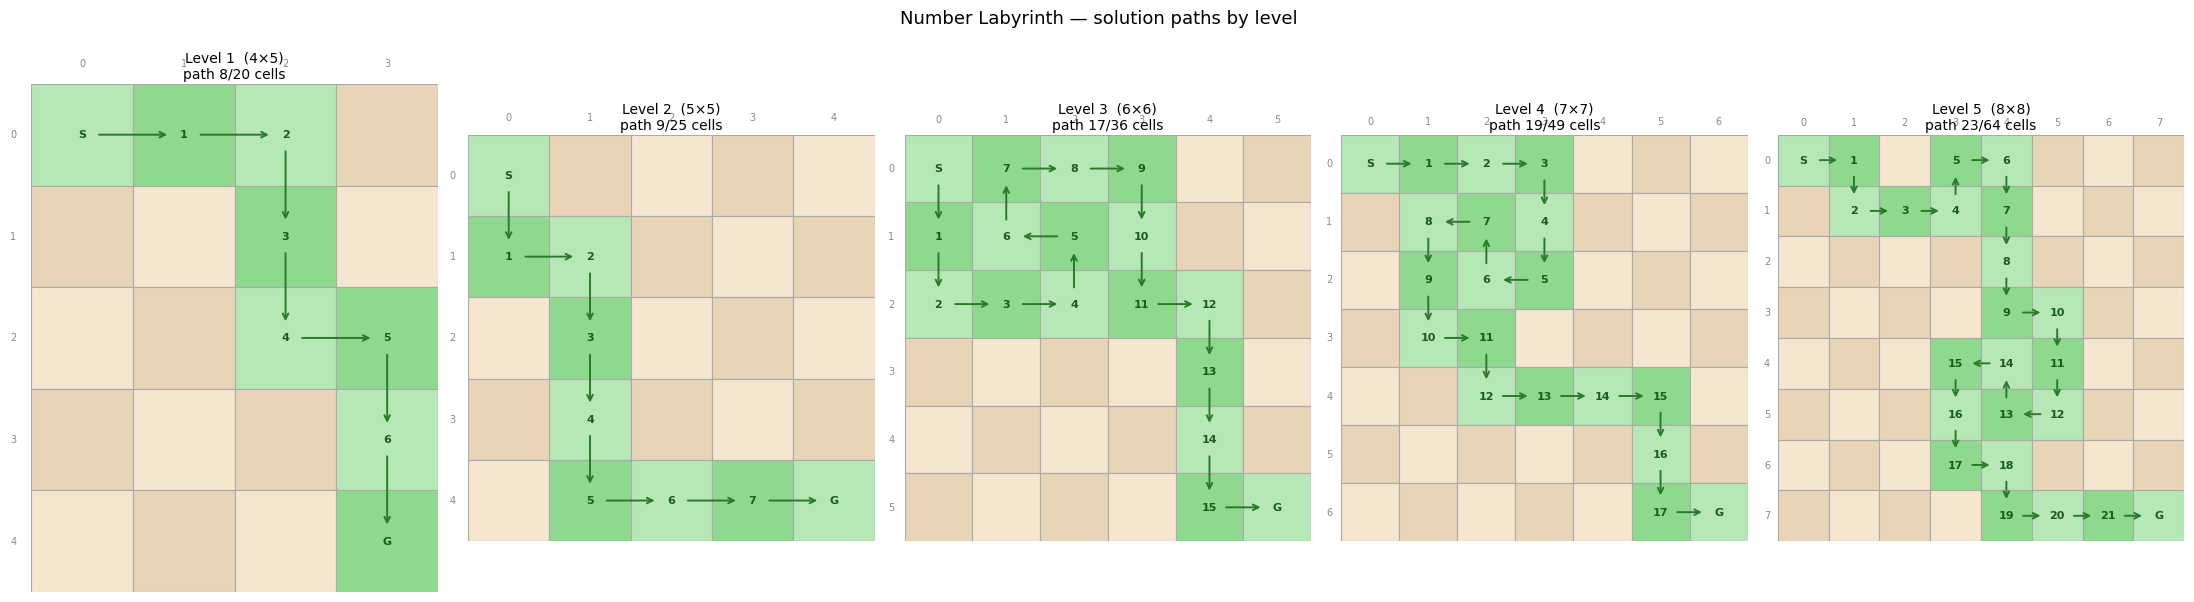

In [4]:
# ── Show one generated path per level ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, (lvl, cfg) in zip(axes, LEVELS.items()):
    cols, rows = cfg['cols'], cfg['rows']
    path = get_solution_path(cols, rows)
    T = cols * rows
    display_path(
        cols, rows, path,
        title=f"Level {lvl}  ({cols}×{rows})\npath {len(path)}/{T} cells",
        ax=ax
    )

plt.suptitle('Number Labyrinth — solution paths by level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4 · Solution-path generator (v2 — BFS exhaustive enumeration)

### Validity constraint
A path is valid when every cell on it satisfies the **neighbour-count rule**:

| Cell role | Required path-neighbours (grid-adjacent cells also on the path) |
|---|---|
| Start `(0,0)` | exactly **1** |
| End `(cols-1, rows-1)` | exactly **1** |
| Any other path cell | exactly **2** |

### Key insight — incremental validity check
When extending the current path from cell `c` to a candidate `nc`, the
constraint reduces to a single fast check:

> **`nc` must have no already-visited spatial neighbour other than `c`.**

Why this is sufficient:
* `nc` currently has exactly 1 path-neighbour (`c`).  When we later leave `nc`
  it will gain its 2nd path-neighbour — satisfying the exactly-2 rule for
  intermediate cells.
* If `nc` already had a *second* visited neighbour `p ≠ c`, then once we step
  away from `nc` it would have 3 path-neighbours → violation.
* Adding `nc` cannot increase the path-neighbour count of any *already-visited*
  cell other than `c`, because the check above guarantees no such adjacency exists.
* For the goal cell the same check ensures it ends up with exactly 1
  path-neighbour (`c`).

### Length-bound pruning
Two optional parameters `min_length` / `max_length` restrict which paths are
returned **and** prune the search tree early:

| Pruning rule | When applied | Rationale |
|---|---|---|
| **Max-length** | before enqueuing `nc` | if `len(path) + manhattan(nc, goal) > max_length`, the goal can never be reached within the budget from this branch → discard |
| **Min-length** | when `nc == goal` | only collect paths with `len(new_path) >= min_length` |

The max-length rule is tight: Manhattan distance is the absolute minimum number
of additional steps needed to reach the goal, so no valid completion of this
branch can satisfy the bound.

In [5]:
def generate_solution_path_2(cols, rows, min_length=None, max_length=None):
    """
    BFS exhaustive enumeration of ALL valid paths from (0,0) to
    (cols-1, rows-1) satisfying the neighbour-count rule:
      - start and end cells have exactly 1 path-neighbour
      - every other path cell has exactly 2 path-neighbours
    (neighbours = grid-adjacent cells: up / down / left / right)

    Parameters
    ----------
    cols, rows  : board dimensions
    min_length  : if given, only paths with len >= min_length are returned
    max_length  : if given, branches where the goal cannot be reached within
                  max_length steps are pruned immediately (using Manhattan
                  distance as a lower bound on remaining steps)

    Returns
    -------
    list of all valid paths, each as a tuple of (col, row) pairs.
    """
    start = (0, 0)
    goal  = (cols - 1, rows - 1)

    def neighbors(c, r):
        return [
            (c + dc, r + dr)
            for dc, dr in DIRS
            if 0 <= c + dc < cols and 0 <= r + dr < rows
        ]

    def manhattan_to_goal(c, r):
        return abs(goal[0] - c) + abs(goal[1] - r)

    # Queue entries: (current_pos, frozenset_of_visited, path_tuple)
    queue = deque([(start, frozenset([start]), (start,))])
    all_paths = []

    while queue:
        pos, visited, path = queue.popleft()

        for nc in neighbors(*pos):
            # Skip already-visited cells (self-avoiding walk)
            if nc in visited:
                continue

            # Validity check: nc must touch the existing path ONLY at pos.
            if any(nb in visited and nb != pos for nb in neighbors(*nc)):
                continue

            new_len = len(path) + 1

            # Max-length pruning: if even the shortest possible completion of
            # this branch (Manhattan distance from nc to goal) would exceed
            # max_length, there is no valid path down this branch → discard.
            if max_length is not None:
                if new_len + manhattan_to_goal(*nc) > max_length:
                    continue

            new_visited = visited | {nc}
            new_path    = path + (nc,)

            if nc == goal:
                # Min-length filter: only collect paths long enough
                if min_length is None or new_len >= min_length:
                    all_paths.append(new_path)
            else:
                queue.append((nc, new_visited, new_path))

    return all_paths


# ── Test on the two smallest boards, with and without length bounds ─────────
for lvl in (1, 2):
    cfg = LEVELS[lvl]
    cols, rows = cfg['cols'], cfg['rows']
    T = cols * rows
    lo = math.floor(0.35 * T)   # same bounds as the game uses
    hi = math.floor(0.55 * T)

    paths_all     = generate_solution_path_2(cols, rows)
    paths_bounded = generate_solution_path_2(cols, rows, min_length=lo, max_length=hi)

    lens_all     = [len(p) for p in paths_all]
    lens_bounded = [len(p) for p in paths_bounded]

    print(
        f"Level {lvl}  ({cols}×{rows})  T={T}"
        f"\n  no bounds   : {len(paths_all):5d} paths   "
        f"length range {min(lens_all)}–{max(lens_all)}"
        f"\n  [{lo}–{hi}] bound: {len(paths_bounded):5d} paths   "
        f"length range {min(lens_bounded)}–{max(lens_bounded)}"
        f"\n"
    )

Level 1  (4×5)  T=20
  no bounds   :    41 paths   length range 8–14
  [7–11] bound:    38 paths   length range 8–10

Level 2  (5×5)  T=25
  no bounds   :    92 paths   length range 9–17
  [8–13] bound:    86 paths   length range 9–13



---
## 5 · Visual comparison: shortest vs. longest paths per level (levels 1–4)

For each level the full set of valid paths is enumerated within the game's
`[35%, 55%]` length window.  One path is sampled at random from those at
the **shortest length actually attained** and one from those at the
**longest length actually attained** within that window, then displayed side by side.
The attained bounds may differ from the window bounds if no valid path exists
at exactly `floor(0.35·T)` or `floor(0.55·T)`.

Layout: 4 rows (one per level) × 2 columns (shortest left, longest right).

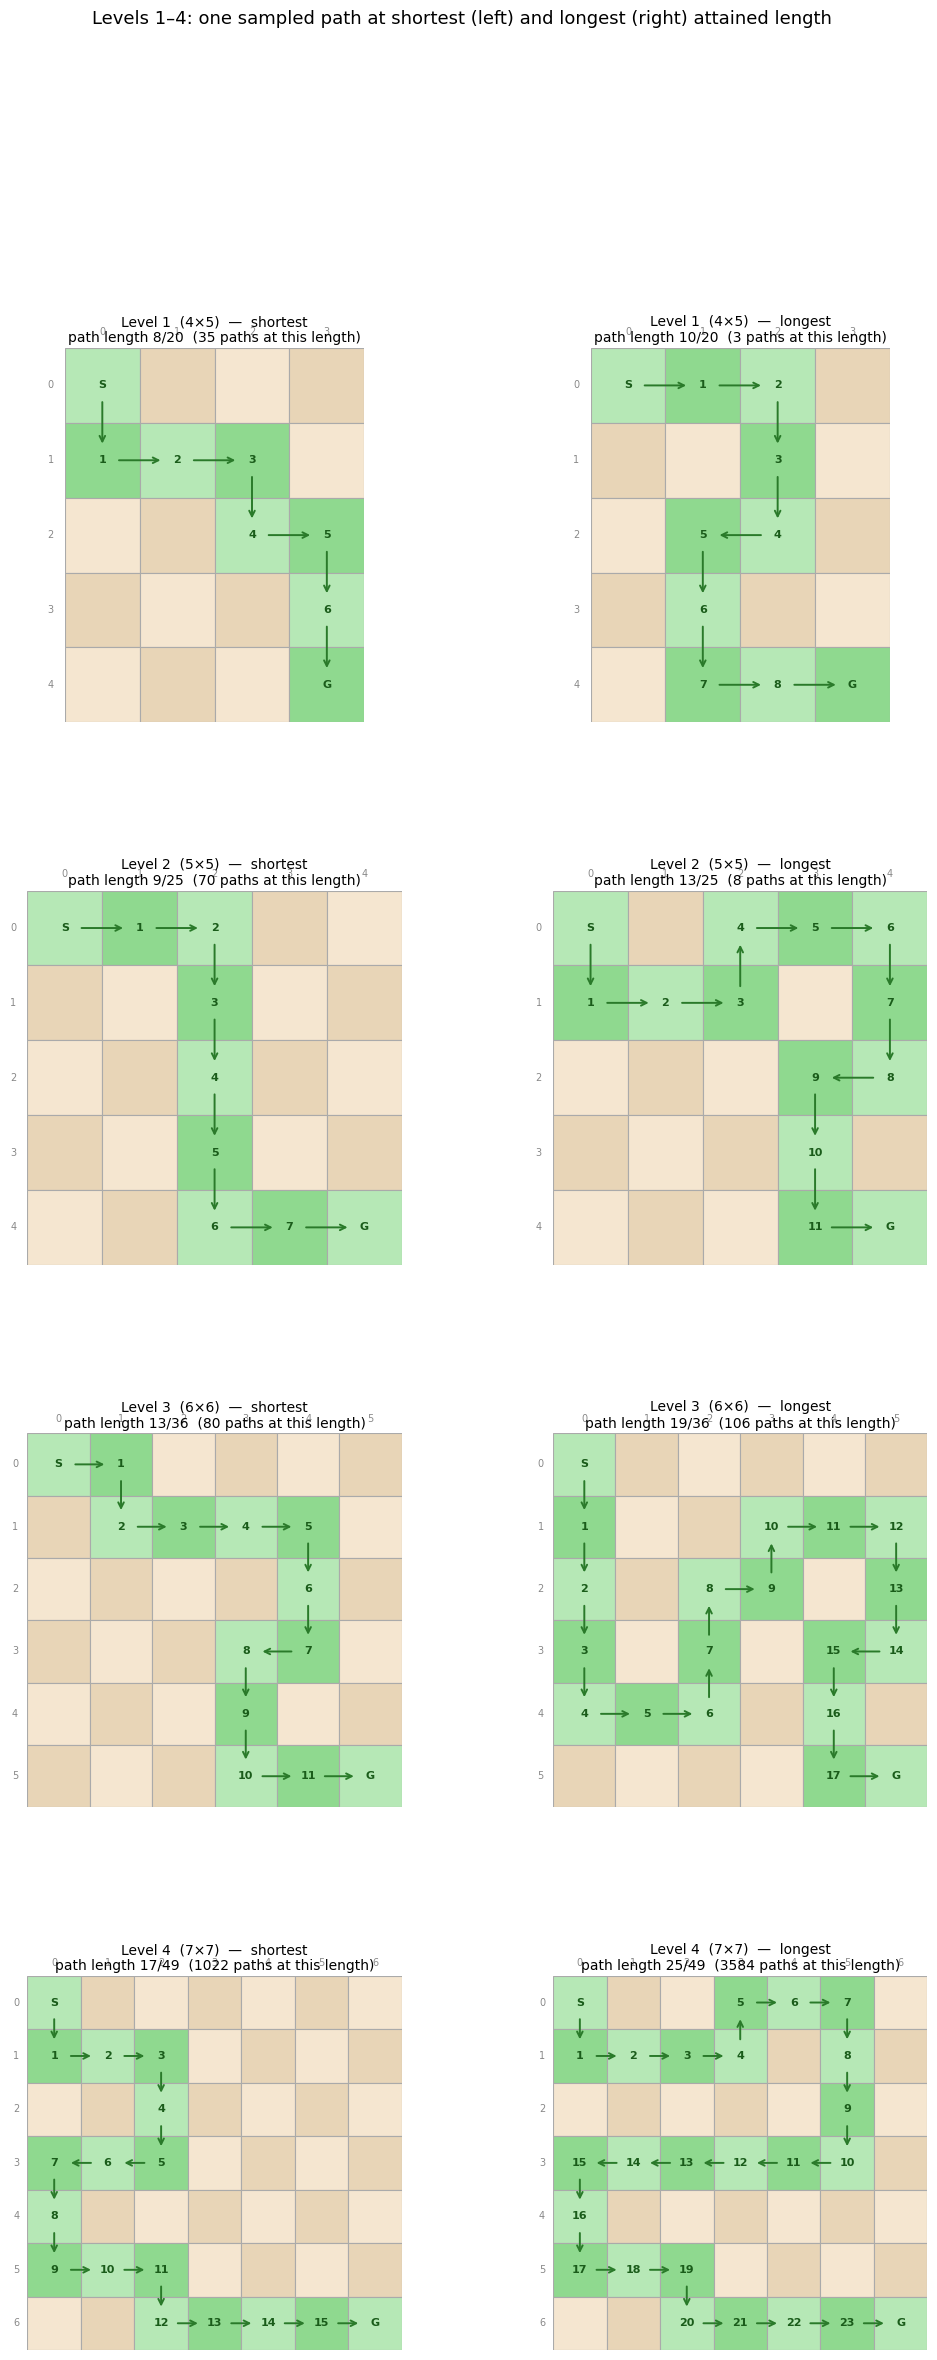

In [6]:
fig, axes = plt.subplots(
    nrows=4, ncols=2,
    figsize=(12, 26),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.3}
)

for row_idx, lvl in enumerate(range(1, 5)):
    cfg = LEVELS[lvl]
    cols, rows = cfg['cols'], cfg['rows']
    T = cols * rows
    lo = math.floor(0.35 * T)
    hi = math.floor(0.55 * T)

    # Enumerate all valid paths within the length window
    paths = generate_solution_path_2(cols, rows, min_length=lo, max_length=hi)

    # Use the actual minimum and maximum lengths present in the result set —
    # the window bounds lo/hi may not be attained for every board size.
    actual_min = min(len(p) for p in paths)
    actual_max = max(len(p) for p in paths)

    at_lo = [p for p in paths if len(p) == actual_min]
    at_hi = [p for p in paths if len(p) == actual_max]

    # Sample one path from each bucket
    sample_lo = random.choice(at_lo)
    sample_hi = random.choice(at_hi)

    ax_lo, ax_hi = axes[row_idx]

    display_path(
        cols, rows, sample_lo,
        title=(
            f"Level {lvl}  ({cols}×{rows})  —  shortest\n"
            f"path length {actual_min}/{T}  "
            f"({len(at_lo)} paths at this length)"
        ),
        ax=ax_lo
    )

    display_path(
        cols, rows, sample_hi,
        title=(
            f"Level {lvl}  ({cols}×{rows})  —  longest\n"
            f"path length {actual_max}/{T}  "
            f"({len(at_hi)} paths at this length)"
        ),
        ax=ax_hi
    )

plt.suptitle(
    'Levels 1–4: one sampled path at shortest (left) and longest (right) attained length',
    fontsize=13, y=1.01
)
plt.show()

---
## 6 · Level 4 — 10 examples at increasing path lengths

Level 4 (7×7, T=49) is enumerated within its `[35%, 55%]` window.  
All distinct lengths actually attained are collected; 10 are chosen at
evenly-spaced indices across that sorted list.  One path is sampled at
random from each chosen length.

Layout: 5 rows × 2 columns (lengths increase left-to-right, top-to-bottom).

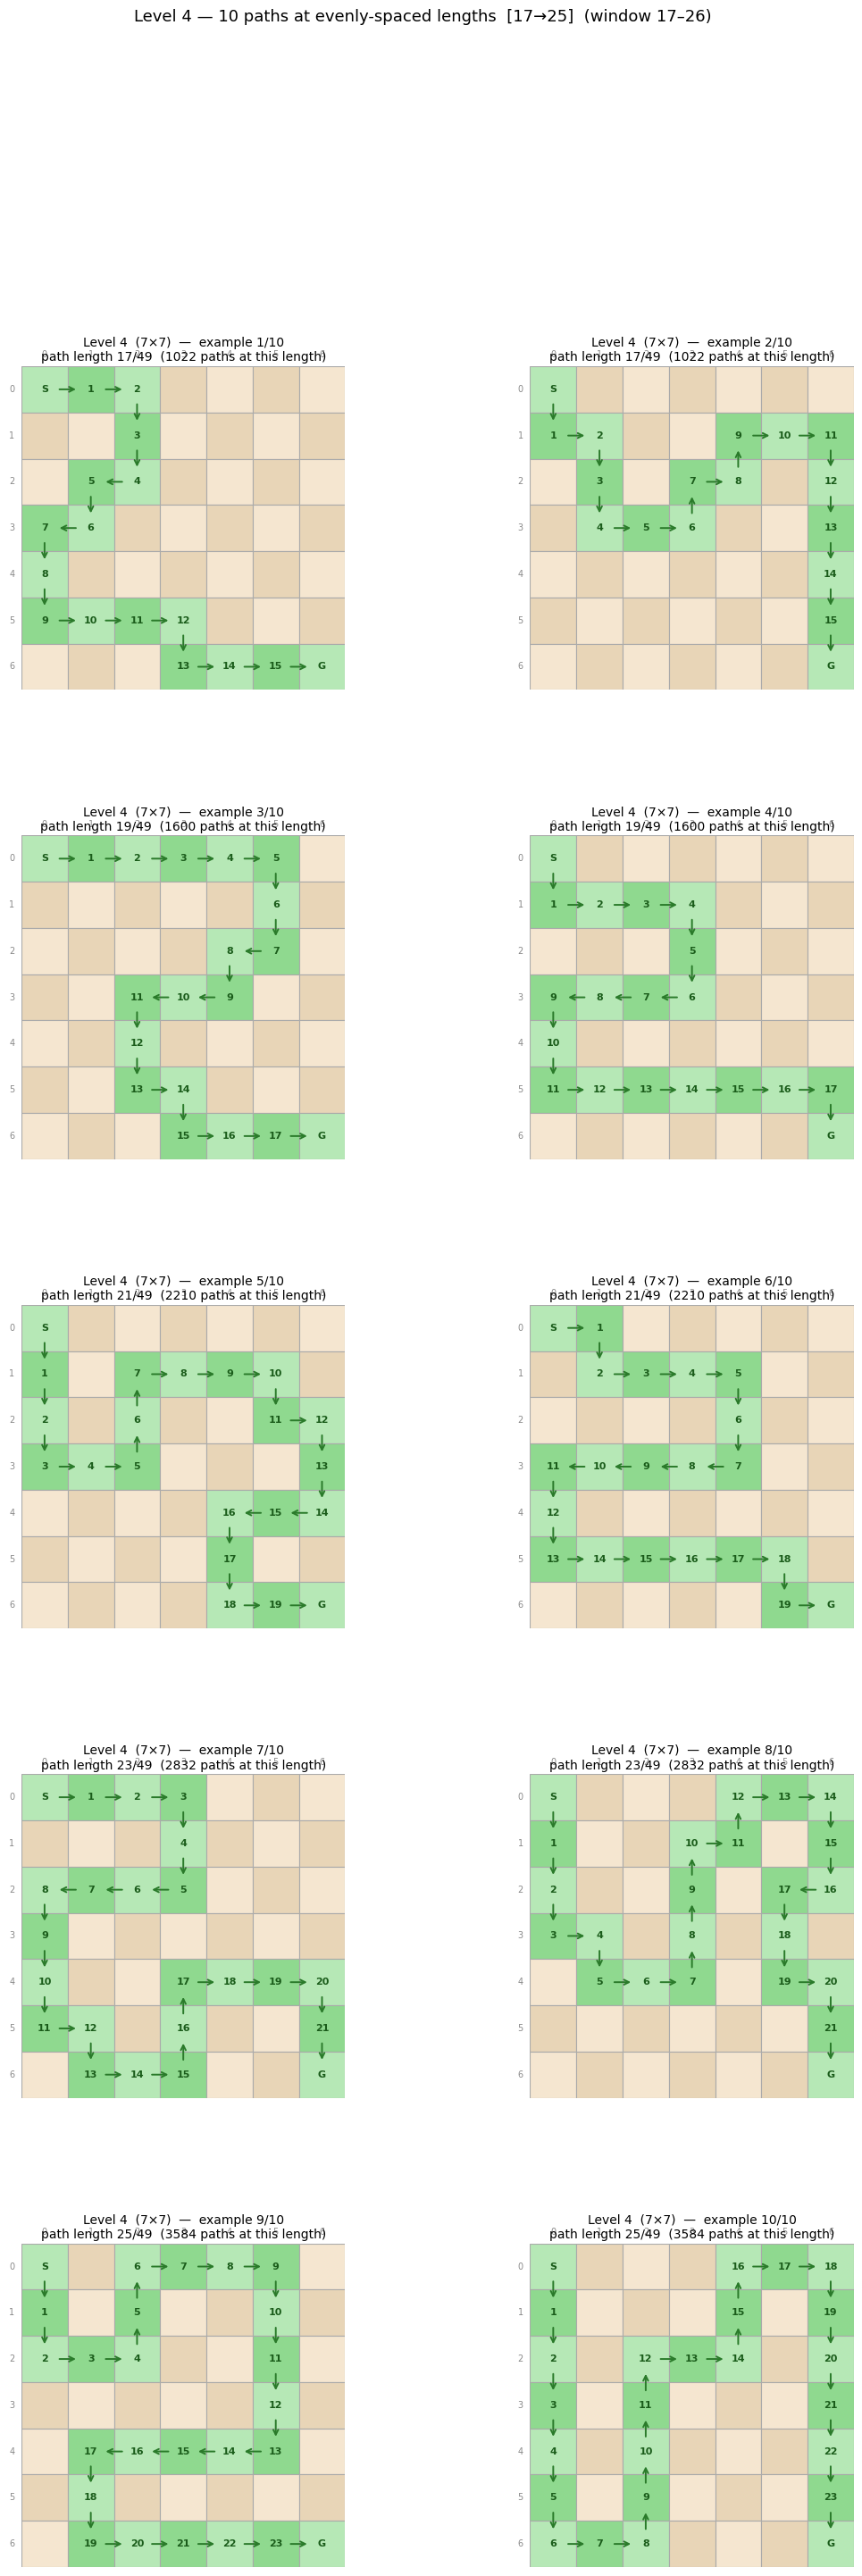

In [7]:
cfg  = LEVELS[4]
cols, rows = cfg['cols'], cfg['rows']
T    = cols * rows
lo   = math.floor(0.35 * T)
hi   = math.floor(0.55 * T)

# Enumerate all valid paths for level 4 within the game's length window
paths_l4 = generate_solution_path_2(cols, rows, min_length=lo, max_length=hi)

# Group by length
from collections import defaultdict
by_length = defaultdict(list)
for p in paths_l4:
    by_length[len(p)].append(p)

# All attained lengths in ascending order
attained = sorted(by_length.keys())

# Pick 10 evenly-spaced indices into the attained list
N = 10
indices = [round(i * (len(attained) - 1) / (N - 1)) for i in range(N)]
chosen_lengths = [attained[i] for i in indices]

# Sample one random path per chosen length
samples = [(l, random.choice(by_length[l])) for l in chosen_lengths]

# ── Plot: 5 rows × 2 columns ─────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=5, ncols=2,
    figsize=(13, 32),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.3}
)

for idx, (length, path) in enumerate(samples):
    ax = axes[idx // 2][idx % 2]
    bucket_size = len(by_length[length])
    display_path(
        cols, rows, path,
        title=(
            f"Level 4  (7×7)  —  example {idx + 1}/10\n"
            f"path length {length}/{T}  "
            f"({bucket_size} paths at this length)"
        ),
        ax=ax
    )

plt.suptitle(
    f'Level 4 — 10 paths at evenly-spaced lengths  '
    f'[{chosen_lengths[0]}→{chosen_lengths[-1]}]  '
    f'(window {lo}–{hi})',
    fontsize=13, y=1.005
)
plt.show()

---
## 7 · DFS single-path generator

### Motivation
`generate_solution_path_2` (BFS) enumerates **all** valid paths, which is
expensive for larger boards.  When only **one** path is needed — as in the
actual game — a depth-first search is far more efficient: it commits to a
branch immediately and returns the first valid solution found, with no need
to materialise the full set.

### Algorithm
Identical validity constraints and pruning rules as the BFS version:
* **Self-avoiding walk** — visited set prevents revisits.
* **Neighbour-count rule** — a candidate cell `nc` is rejected if it touches
  any already-visited cell other than the current position.
* **Max-length pruning** — branches whose shortest possible completion
  (Manhattan distance to goal) would exceed `max_length` are discarded.
* **Min-length filter** — the goal is accepted only when the path is long
  enough.

The only structural differences are:
| | BFS | DFS |
|---|---|---|
| Frontier | queue (FIFO) | stack (LIFO) |
| Explores | breadth-first | depth-first |
| Returns | all valid paths | **first** valid path found |
| Randomness | — | neighbours shuffled before pushing |

Shuffling neighbours before pushing them onto the stack gives a different
random path each call without any outer retry loop.

In [8]:
def generate_solution_path_dfs(cols, rows, min_length=None, max_length=None, rng=None):
    """
    DFS single-path generator: returns ONE valid path from (0,0) to
    (cols-1, rows-1) satisfying the neighbour-count rule, within optional
    length bounds.

    Parameters
    ----------
    cols, rows  : board dimensions
    min_length  : only accept the goal when len(path) >= min_length
    max_length  : prune branches where (current_len + manhattan_to_goal) > max_length
    rng         : a random.Random instance (or None to use the global RNG).
                  Pass a seeded instance for reproducibility.

    Returns
    -------
    A tuple of (col, row) pairs, or None if no valid path exists.
    """
    if rng is None:
        rng = random

    start = (0, 0)
    goal  = (cols - 1, rows - 1)

    def neighbors(c, r):
        return [
            (c + dc, r + dr)
            for dc, dr in DIRS
            if 0 <= c + dc < cols and 0 <= r + dr < rows
        ]

    def manhattan_to_goal(c, r):
        return abs(goal[0] - c) + abs(goal[1] - r)

    # Stack entries: (current_pos, frozenset_of_visited, path_tuple)
    stack = [(start, frozenset([start]), (start,))]

    while stack:
        pos, visited, path = stack.pop()

        # Collect and shuffle candidates to get a fresh random path each call
        candidates = list(neighbors(*pos))
        rng.shuffle(candidates)

        for nc in candidates:
            if nc in visited:
                continue

            # Neighbour-count validity: nc may only touch the path at pos
            if any(nb in visited and nb != pos for nb in neighbors(*nc)):
                continue

            new_len = len(path) + 1

            # Max-length pruning (Manhattan distance is a tight lower bound)
            if max_length is not None:
                if new_len + manhattan_to_goal(*nc) > max_length:
                    continue

            new_path    = path + (nc,)
            new_visited = visited | {nc}

            if nc == goal:
                if min_length is None or new_len >= min_length:
                    return new_path          # ← first valid path found
                # goal reached but path too short — don't push, just skip
            else:
                stack.append((nc, new_visited, new_path))

    return None  # exhausted all branches, no valid path found

In [9]:
import time

# ── 1. Correctness: every DFS path must appear in the BFS-enumerated set ────
print("=== Correctness check ===")
for lvl in range(1, 5):
    cfg = LEVELS[lvl]
    cols, rows = cfg['cols'], cfg['rows']
    T  = cols * rows
    lo = math.floor(0.35 * T)
    hi = math.floor(0.55 * T)

    bfs_set = set(generate_solution_path_2(cols, rows, min_length=lo, max_length=hi))

    ok = True
    for seed in range(20):
        p = generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi,
                                        rng=random.Random(seed))
        if p not in bfs_set:
            print(f"  Level {lvl} seed {seed}: path NOT in BFS set — FAIL")
            ok = False
    print(f"  Level {lvl}  ({cols}×{rows})  window [{lo}–{hi}]: 20 DFS paths all in BFS set — {'OK' if ok else 'FAIL'}")

# ── 2. Speed: DFS vs BFS for levels 1–4 ─────────────────────────────────────
print("\n=== Timing: single path (DFS) vs full enumeration (BFS), 10 runs each ===")
RUNS = 10
for lvl in range(1, 5):
    cfg = LEVELS[lvl]
    cols, rows = cfg['cols'], cfg['rows']
    T  = cols * rows
    lo = math.floor(0.35 * T)
    hi = math.floor(0.55 * T)

    t0 = time.perf_counter()
    for _ in range(RUNS):
        generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi)
    dfs_ms = (time.perf_counter() - t0) / RUNS * 1000

    t0 = time.perf_counter()
    for _ in range(RUNS):
        generate_solution_path_2(cols, rows, min_length=lo, max_length=hi)
    bfs_ms = (time.perf_counter() - t0) / RUNS * 1000

    print(f"  Level {lvl}  ({cols}×{rows})  DFS {dfs_ms:6.1f} ms   BFS {bfs_ms:7.1f} ms   "
          f"speed-up ×{bfs_ms/dfs_ms:.0f}")

=== Correctness check ===
  Level 1  (4×5)  window [7–11]: 20 DFS paths all in BFS set — OK
  Level 2  (5×5)  window [8–13]: 20 DFS paths all in BFS set — OK
  Level 3  (6×6)  window [12–19]: 20 DFS paths all in BFS set — OK
  Level 4  (7×7)  window [17–26]: 20 DFS paths all in BFS set — OK

=== Timing: single path (DFS) vs full enumeration (BFS), 10 runs each ===
  Level 1  (4×5)  DFS    0.1 ms   BFS     1.0 ms   speed-up ×14
  Level 2  (5×5)  DFS    0.1 ms   BFS     3.1 ms   speed-up ×34
  Level 3  (6×6)  DFS    0.6 ms   BFS    48.6 ms   speed-up ×83
  Level 4  (7×7)  DFS    0.8 ms   BFS  1387.1 ms   speed-up ×1731


Level 5  (8×8)  T=64  window [22–35]

Timing over 50 runs
  total   : 446.5 ms
  per call: 8.93 ms  (mean)

Path-length distribution across 50 runs  (window [22–35])
  len 23:  14x  ██████████████
  len 25:   5x  █████
  len 27:   6x  ██████
  len 29:   8x  ████████
  len 31:   8x  ████████
  len 33:   4x  ████
  len 35:   5x  █████

  min length seen: 23
  max length seen: 35
  mean           : 27.9


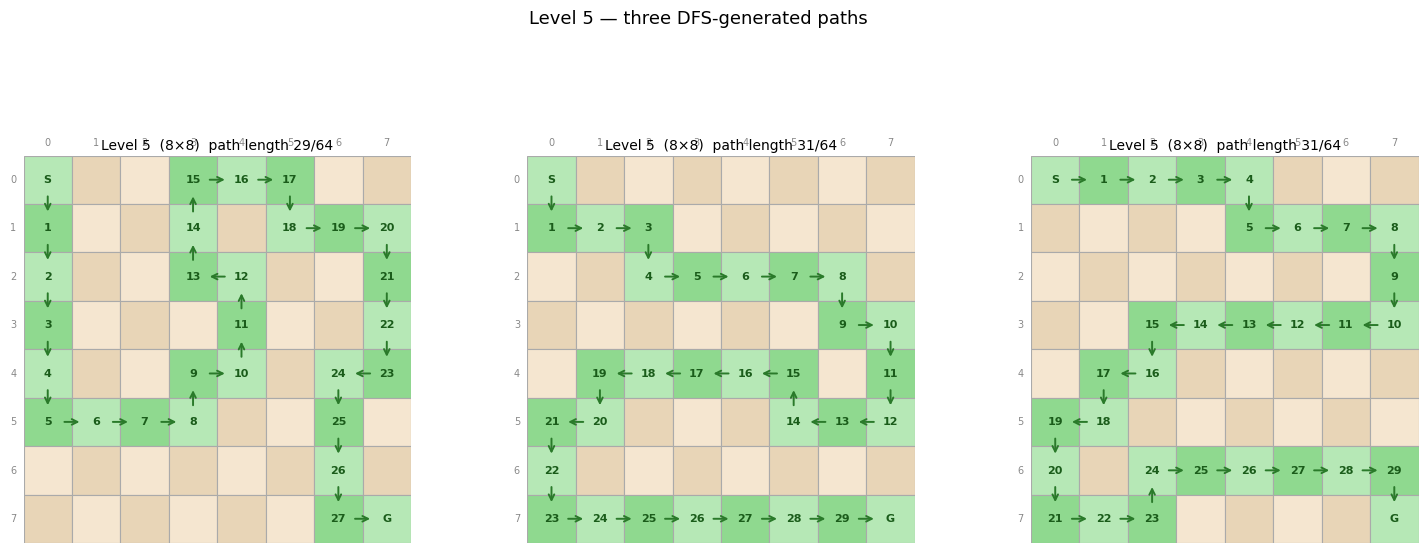

In [10]:
# ── Level 5 — DFS timing & path-length distribution (BFS is too slow here) ──
cfg  = LEVELS[5]
cols, rows = cfg['cols'], cfg['rows']
T    = cols * rows
lo   = math.floor(0.35 * T)
hi   = math.floor(0.55 * T)

print(f"Level 5  ({cols}×{rows})  T={T}  window [{lo}–{hi}]")

# --- Timing: 50 independent runs ---
RUNS = 50
lengths = []
t0 = time.perf_counter()
for seed in range(RUNS):
    p = generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi,
                                    rng=random.Random(seed))
    assert p is not None, f"seed {seed}: no path found"
    lengths.append(len(p))
elapsed = time.perf_counter() - t0

print(f"\nTiming over {RUNS} runs")
print(f"  total   : {elapsed*1000:.1f} ms")
print(f"  per call: {elapsed/RUNS*1000:.2f} ms  (mean)")

print(f"\nPath-length distribution across {RUNS} runs  (window [{lo}–{hi}])")
from collections import Counter
cnt = Counter(lengths)
for l in sorted(cnt):
    bar = '█' * cnt[l]
    print(f"  len {l:2d}: {cnt[l]:3d}x  {bar}")

print(f"\n  min length seen: {min(lengths)}")
print(f"  max length seen: {max(lengths)}")
print(f"  mean           : {sum(lengths)/len(lengths):.1f}")

# --- Show 3 sample paths side by side ---
samples = [
    generate_solution_path_dfs(cols, rows, min_length=lo, max_length=hi,
                                rng=random.Random(s))
    for s in (0, 7, 42)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7), gridspec_kw={'wspace': 0.3})
for ax, path in zip(axes, samples):
    display_path(cols, rows, path,
                 title=f"Level 5  (8×8)  path length {len(path)}/{T}",
                 ax=ax)
plt.suptitle('Level 5 — three DFS-generated paths', fontsize=13)
plt.show()